In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [2]:
# Definir la función f(x) = x^3 - 4x + sin(5x)
def f(x):
    return x ** 3 - 4 * x + np.sin(5 * x)


# Definir la derivada f'(x)
def df(x):
    return 3 * x ** 2 - 4 + 5 * np.cos(5 * x)



In [3]:
# Crear valores de x en un rango adecuado
x = np.linspace(-2.5, 2.5, 400)
y = f(x)

# Parámetros del algoritmo de gradiente
learning_rate = 0.01  # Tasa de aprendizaje (alpha)
tol = 1e-6
max_iter = 50

# Inicializar listas para almacenar el recorrido de los puntos
x_vals_min, y_vals_min = [], []
x_vals_max, y_vals_max = [], []



In [4]:

# Gradiente Descendente (mínimos)
x_min = -.7  # Punto inicial más adecuado para encontrar mínimo
for _ in range(max_iter):
    grad = df(x_min)
    if abs(grad) < tol:
        break
    x_min -= learning_rate * grad
    x_vals_min.append(float(x_min))
    y_vals_min.append(float(f(x_min)))

# Gradiente Ascendente (máximos)
x_max = 0.8 # Punto inicial más adecuado para encontrar máximo
for _ in range(max_iter):
    grad = df(x_max)
    if abs(grad) < tol:
        break
    x_max += learning_rate * grad
    x_vals_max.append(float(x_max))
    y_vals_max.append(float(f(x_max)))


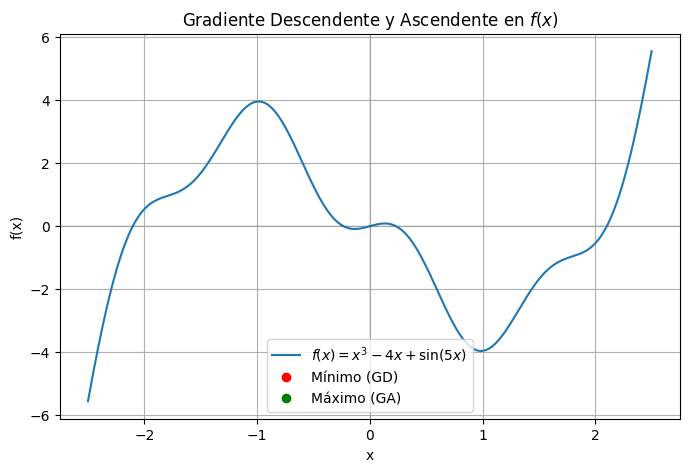

In [5]:
# Crear figura para la animación
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, label=r"$f(x) = x^3 - 4x + \sin(5x)$")
ax.axhline(0, color="black", linewidth=0.15, linestyle="--")
ax.axvline(0, color="black", linewidth=0.15, linestyle="--")

# Marcar los puntos críticos en la animación
point_min, = ax.plot([], [], 'ro', markersize=6, label="Mínimo (GD)")
point_max, = ax.plot([], [], 'go', markersize=6, label="Máximo (GA)")

# Línea de trayectoria
path_min, = ax.plot([], [], 'r-', alpha=0.5)
path_max, = ax.plot([], [], 'g-', alpha=0.5)

# Configuración de ejes
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("Gradiente Descendente y Ascendente en $f(x)$")
ax.legend()
ax.grid(True)



In [6]:
# Función de actualización para la animación
def update(frame):
    if frame < len(x_vals_min):
        point_min.set_data([x_vals_min[frame]], [y_vals_min[frame]])
        path_min.set_data(x_vals_min[:frame + 1], y_vals_min[:frame + 1])  # Dibujar la trayectoria

    if frame < len(x_vals_max):
        point_max.set_data([x_vals_max[frame]], [y_vals_max[frame]])
        path_max.set_data(x_vals_max[:frame + 1], y_vals_max[:frame + 1])  # Dibujar la trayectoria

    return point_min, point_max, path_min, path_max


# Crear la animación (blit=False para PyCharm)
ani = animation.FuncAnimation(fig, update, frames=max(len(x_vals_min), len(x_vals_max)), interval=2, blit=False)


# **Guardar la animación como GIF**
gif_filename = "gradiente_2d.gif"
ani.save(gif_filename, writer="pillow", fps=10)

print(f"Animación guardada como {gif_filename}")


Animación guardada como gradiente_2d.gif


In [8]:

# Mostrar la animación
plt.show()
